### SIAC-Based Fourier Filters for FBP

This notebook verifies the construction of SIAC-based Fourier filters to be used directly within the FBP operator, including implementation through ODL's built-in FBP framework.

The notebook is used to test parameter configurations, study stability and conditioning, and determine which SIAC-based filter designs are suitable for the Monte Carlo experiments.

In [2]:
import numpy as np
import pandas as pd
import odl
import matplotlib.pyplot as plt
import sys
sys.path.append("../..")

In [3]:
from src.siac_fourier import siac_filter_odl

from src.tomo import(
    make_space_2d, 
    shepp_logan_2d, 
    parallel_geom_2d, 
    ray_transform_2d, 
    reconstruct_fbp, 
    add_relative_gaussian_noise
)

from src.metrics import(
    rel_l2_err, 
    ssim, 
    gradient_weighted_ssim, 
    eval_metrics, 
    build_metrics_table
)

from src.plotting_helpers import (
    plot_img, 
    plot_img_zoom, 
    save_image_w_zoom
)


/home/ahopkins/KTH_TTMAM/MEX/odl_xray/venv/lib/python3.10/site-packages/odl/util/utility.py:1398: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_requirements


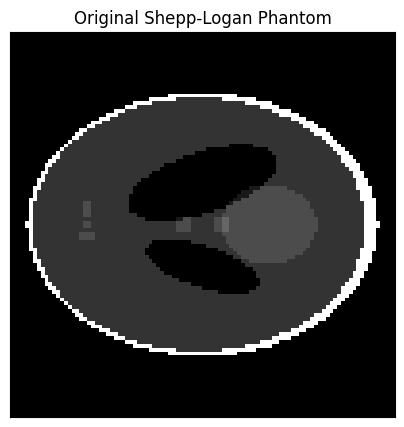

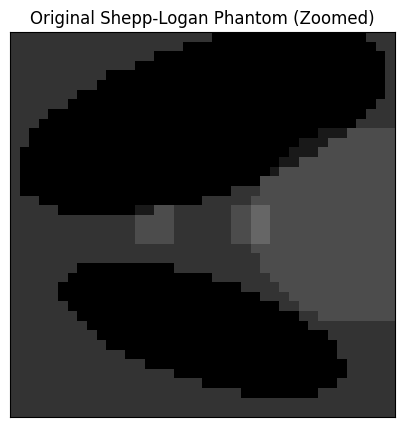

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Original Shepp-Logan Phantom (Zoomed)'}>)

In [4]:
### Create the reconstruction space and phantom ###

xmin, xmax, ymin, ymax = -20, 20, -20, 20
Nx, Ny = 100, 100

space = make_space_2d(Nx=Nx, Ny=Ny, domain=[xmin, xmax, ymin, ymax])
phantom = shepp_logan_2d(space)
phantom_np = phantom.asarray()

# Full angular coverage (mimic CT)
angular_coverage=(-90,90)
step = 3                    # angular resolution (3 degrees per step)

# detector half-width should be at least the half-diagonal of the reconstruction box
r = np.sqrt((0.5*(xmax - xmin))**2 + (0.5*(ymax - ymin))**2)
det_range = (-r, r)

det_count = int(np.ceil(1.5 * np.sqrt(Nx**2 + Ny**2)))

geom = parallel_geom_2d(angular_coverage=angular_coverage, step=step, 
                        det_range=det_range, det_count=det_count)
A = ray_transform_2d(space, geom)
data_space = A.range

sinogram = A(phantom)

# testing with 10% Noise here
sino_noisy = add_relative_gaussian_noise(sinogram, rel_level=0.1)

plot_img(img=phantom, title="Original Shepp-Logan Phantom")
plot_img_zoom(img=phantom, title="Original Shepp-Logan Phantom (Zoomed)")

In [5]:
### Compute the FBP with the ramp filter only and Hann window

# Create a Noisy phantom using the FBP
filter_used = "Ram-Lak"
fbp_ramp = reconstruct_fbp(sino_noisy, A, filter_name=filter_used)
fbp_hann = reconstruct_fbp(sino_noisy, A, filter_name="Hann")

### Adjust ODL function to accept custom filter

**NOTE**: For the ODL version used here (0.8.3) there was a bug in the function:
odl.tomo.analytic.filtered_back_projection used for backprojection. This "monkey-patches" it.

In [6]:
import odl, inspect
import odl.tomo.analytic.filtered_back_projection as fbpmod
print(odl.__version__)
print(inspect.getsource(fbpmod._fbp_filter))

0.8.3
def _fbp_filter(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    filter_ty

In [7]:
def _fbp_filter_patched(norm_freq, filter_type, frequency_scaling):
    """Create a smoothing filter for FBP.

    Parameters
    ----------
    norm_freq : `array-like`
        Frequencies normalized to lie in the interval [0, 1].
    filter_type : {'Ram-Lak', 'Shepp-Logan', 'Cosine', 'Hamming', 'Hann',
                   callable}
        The type of filter to be used.
        If a string is given, use one of the standard filters with that name.
        A callable should take an array of values in [0, 1] and return the
        filter for these frequencies.
    frequency_scaling : float
        Scaling of the frequencies for the filter. All frequencies are scaled
        by this number, any relative frequency above ``frequency_scaling`` is
        set to 0.

    Returns
    -------
    smoothing_filter : `numpy.ndarray`

    Examples
    --------
    Create an FBP filter

    >>> norm_freq = np.linspace(0, 1, 10)
    >>> filt = _fbp_filter(norm_freq,
    ...                    filter_type='Hann',
    ...                    frequency_scaling=0.8)
    """
    # filter_type, filter_type_in = str(filter_type).lower(), filter_type
    filter_type_in = filter_type    # Add this for error message
    if callable(filter_type):
        filt = filter_type(norm_freq)
    else:   # add else here for string-based call (e.g. "hann")
        filter_type = str(filter_type).lower()
        if filter_type == 'ram-lak':
            filt = np.copy(norm_freq)
        elif filter_type == 'shepp-logan':
            filt = norm_freq * np.sinc(norm_freq / (2 * frequency_scaling))
        elif filter_type == 'cosine':
            filt = norm_freq * np.cos(norm_freq * np.pi / (2 * frequency_scaling))
        elif filter_type == 'hamming':
            filt = norm_freq * (
                0.54 + 0.46 * np.cos(norm_freq * np.pi / (frequency_scaling)))
        elif filter_type == 'hann':
            filt = norm_freq * (
                np.cos(norm_freq * np.pi / (2 * frequency_scaling)) ** 2)
        else:
            raise ValueError('unknown `filter_type` ({})'
                            ''.format(filter_type_in))

    indicator = (norm_freq <= frequency_scaling)
    filt *= indicator
    return filt


# Patch
fbpmod._fbp_filter = _fbp_filter_patched


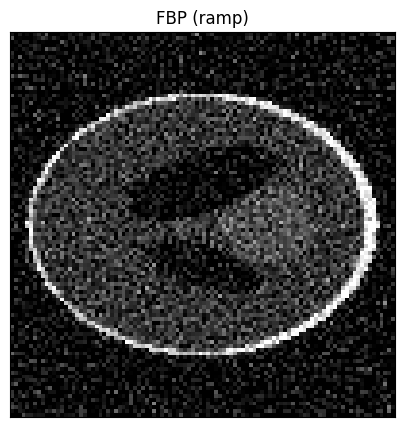

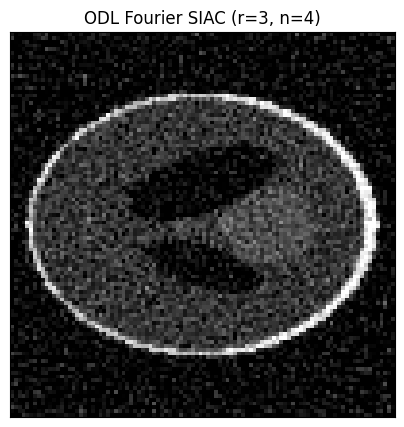

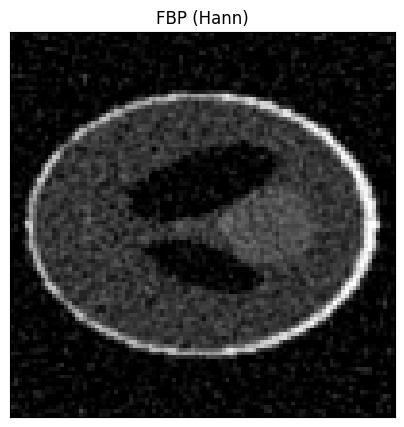

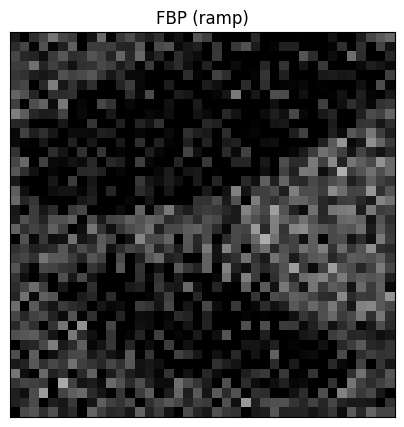

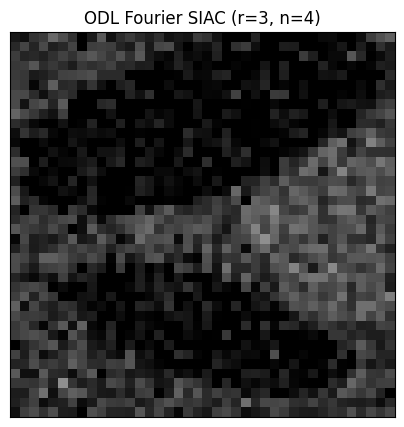

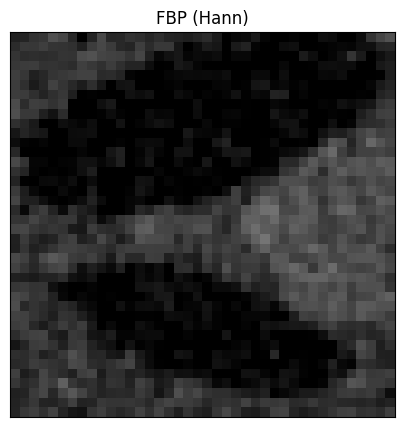

(<Figure size 500x500 with 1 Axes>, <Axes: title={'center': 'FBP (Hann)'}>)

In [8]:
# SIAC Parameters
moments = 2
BSorder = 4

# Pass costom filter to ODL and fetch FBP operator
fbp_siac_op = odl.tomo.fbp_op(
    A,
    filter_type=siac_filter_odl(moments=moments, BSorder=BSorder),
    padding=True,
    frequency_scaling=1.0
)
fbp_siac_odl = fbp_siac_op(sino_noisy)
fbp_siac = fbp_siac_odl.asarray()

plot_img(img=fbp_ramp, title=f"FBP (ramp)")
plot_img(img=fbp_siac, title=f"ODL Fourier SIAC (r={moments+1}, n={BSorder})")
plot_img(img=fbp_hann, title="FBP (Hann)")

plot_img_zoom(img=fbp_ramp, title=f"FBP (ramp)")
plot_img_zoom(img=fbp_siac, title=f"ODL Fourier SIAC (r={moments+1}, n={BSorder})")
plot_img_zoom(img=fbp_hann, title="FBP (Hann)")

### Testing more parameters

**Note** Recall from verification/00_siac_kernel_checks.ipynb the unstability (high condition number) from going above preserving 10 moments.

In [9]:
momentss = [2, 4, 6, 8, 10]
BSorders = [1, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 20]

cases = {
    "FBP-ramp": {
        "image": fbp_ramp.asarray(),
        "extra": {"method": "FBP", "filter": "ramp"},
    },
    "FBP-Hann": {
        "image": fbp_hann.asarray(),
        "reference": fbp_ramp.asarray(),
        "extra": {"method": "FBP", "filter": "hann"},
    },
}

for r in momentss:
    for n in BSorders:
        # Build operator
        fbp_siac_op = odl.tomo.fbp_op(
            A,
            filter_type=siac_filter_odl(moments=r, BSorder=n),
            padding=True,
            frequency_scaling=1.0
        )
        # Backproject
        fbp_siac_odl = fbp_siac_op(sino_noisy)
        # from odl element --> array
        fbp_siac = fbp_siac_odl.asarray()
        
        name = f"SIAC ODL window r{r+1} n{n}"

        cases[name] = {
            "image": fbp_siac,
            "reference": fbp_ramp.asarray(),
            "extra": {
                "method": "Fourier-SIAC-Window",
                "filter": "ramp",
                "moments": r+1,
                "BSorder": n,
            },
        }
   
dx, dy = space.cell_sides           # physical grid spacing (x, y)
_, d_det = data_space.cell_sides    # (angular res (rad), detector spacing)
     
df = build_metrics_table(cases, truth=phantom_np, dx=dx, dy=dy, compute_reference_metrics=False)

# Since we ran a lot of experiments, we pick out the best 3 w.r.t.
# The relative L2 error, masked relative L2 error, gradient weighted SSIM, and SSIM
df_siac = df[df["method"] == "Fourier-SIAC-Window"].copy()

best_3_l2_row = df_siac.nsmallest(3, "rel_l2_err")
best_3_masked_l2_row = df_siac.nsmallest(3, "masked_rel_l2_err")
best_3_gw_ssim = df_siac.nlargest(3, "gw_ssim")
best_3_ssim = df_siac.nlargest(3, "ssim")

df_summary = pd.concat([
    df.loc[df["name"] == "FBP-ramp"].iloc[[0]].assign(selected_as="baseline"),
    df.loc[df["name"] == "FBP-Hann"].iloc[[0]].assign(selected_as="baseline"),
    best_3_l2_row.assign(selected_as="best SIAC rel_l2"),
    best_3_masked_l2_row.assign(selected_as="best SIAC masked_rel_l2"),
    best_3_gw_ssim.assign(selected_as="best SIAC gw_ssim"),
    best_3_ssim.assign(selected_as="best SIAC ssim"),
], ignore_index=True)

cols = ["selected_as"] + [c for c in df_summary.columns if c != "selected_as"]
df_summary = df_summary[cols]

# Drop duplicates
df_summary = df_summary.drop_duplicates(subset=["name"])

df_summary

,selected_as,name,rel_l2_err,ssim,gw_ssim,masked_rel_l2_err,gradient_error,method,filter,moments,BSorder
0,baseline,FBP-ramp,0.613357,0.290151,0.800256,0.449554,1.026095,FBP,ramp,NaN,NaN
1,baseline,FBP-Hann,0.383321,0.435581,0.829495,0.348247,0.633476,FBP,hann,NaN,NaN
2,best SIAC rel_l2,SIAC ODL window r3 n16,0.380000,0.447661,0.833845,0.347863,0.626568,Fourier-SIAC-Window,ramp,3.0,16.0
3,best SIAC rel_l2,SIAC ODL window r3 n14,0.380121,0.434043,0.839140,0.342479,0.628841,Fourier-SIAC-Window,ramp,3.0,14.0
4,best SIAC rel_l2,SIAC ODL window r5 n20,0.381825,0.425340,0.843205,0.339973,0.632875,Fourier-SIAC-Window,ramp,5.0,20.0
5,best SIAC masked_rel_l2,SIAC ODL window r5 n14,0.393033,0.395688,0.849689,0.333819,0.658389,Fourier-SIAC-Window,ramp,5.0,14.0
6,best SIAC masked_rel_l2,SIAC ODL window r5 n12,0.401239,0.384602,0.850467,0.334037,0.673867,Fourier-SIAC-Window,ramp,5.0,12.0
7,best SIAC masked_rel_l2,SIAC ODL window r3 n8,0.399504,0.386345,0.849159,0.334253,0.668638,Fourier-SIAC-Window,ramp,3.0,8.0
8,best SIAC gw_ssim,SIAC ODL window r7 n16,0.403365,0.382848,0.850498,0.334721,0.679082,Fourier-SIAC-Window,ramp,7.0,16.0
10,best SIAC gw_ssim,SIAC ODL window r7 n14,0.411790,0.374322,0.850274,0.336290,0.693988,Fourier-SIAC-Window,ramp,7.0,14.0


From these results, together with the plots below, we observe that the same conclusions as in the previous notebook (**research/02b_siac_fbp_detector_filter.ipynb**) hold. This is consistent with theory, as the two approaches are mathematically equivalent.

The filtered backprojection (FBP) reconstruction is given by
$$
u = \mathcal{R}^\ast \left( h * (\mathcal{R}u) \right),
$$
where $h$ is the reconstruction filter.

In Fourier space (with respect to the detector variable), this corresponds to
$$
\widehat{h}(t) = |t| \cdot W(t),
$$
where $W(t)$ is a window function.

**Approach 1 (previous notebook)**

* Apply SIAC filtering in the detector variable:
$$
\widehat{g}_{\text{filtered}}(t) = \widehat{K}(t)\,\widehat{g}(t),
$$
* Apply the standard ramp filter:
$$
\widehat{h}(t) = |t|.
$$


This yields the combined effect
$$
|t| \cdot \widehat{K}(t).
$$

**Approach 2 (this notebook)**
Define the reconstruction filter directly as
$$
\widehat{h}(t) = |t| \cdot \widehat{K}(t),
$$
and use this filter in the FBP procedure.


Hence, both approaches result in the same effective filter in Fourier space, and are therefore mathematically equivalent. The only difference lies in the order in which the operations are applied (pre-filtering of the sinogram versus modifying the reconstruction filter).

Consequently, the conclusions regarding parameter selection, namely that moderate moment reproduction ($r \approx 3$--$7$) combined with high smoothness ($n \approx 8$--$20$) yields the most robust reconstructions, are consistent across both implementations.

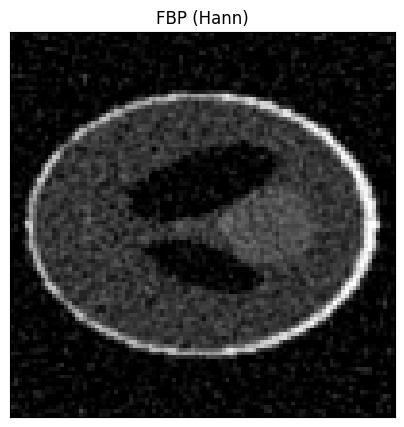

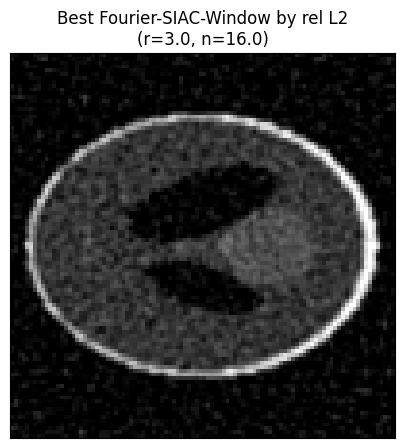

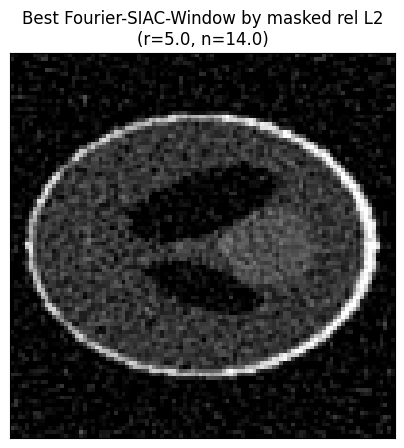

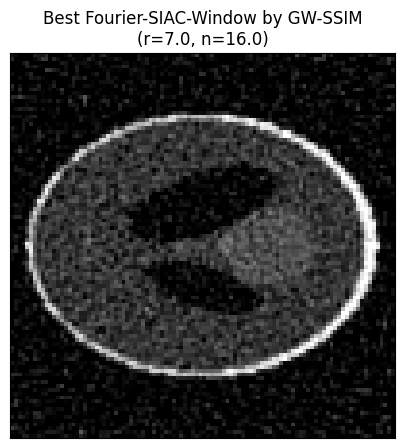

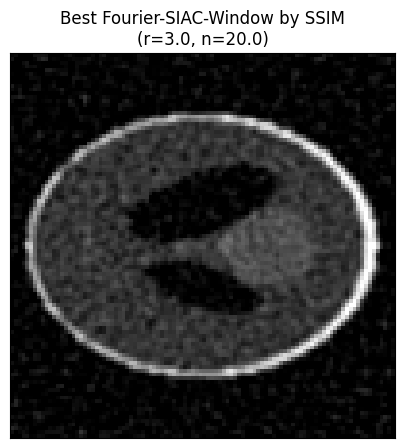

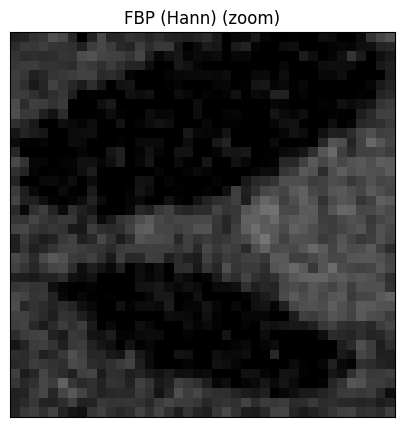

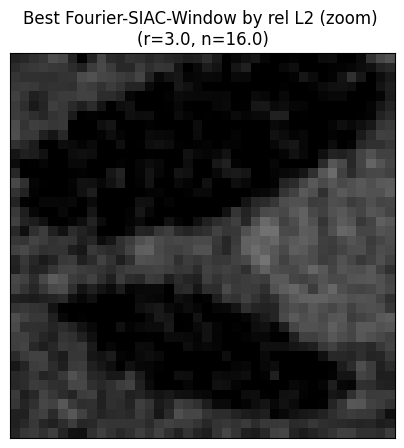

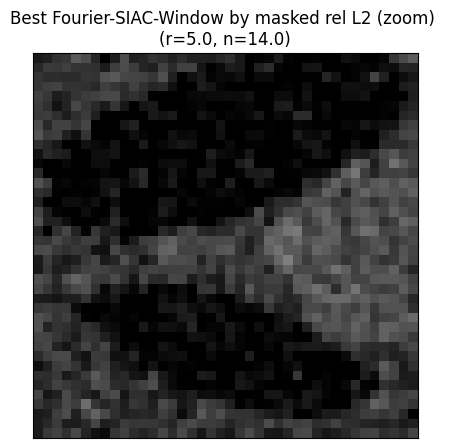

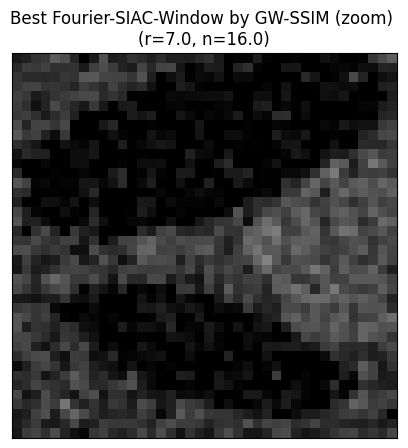

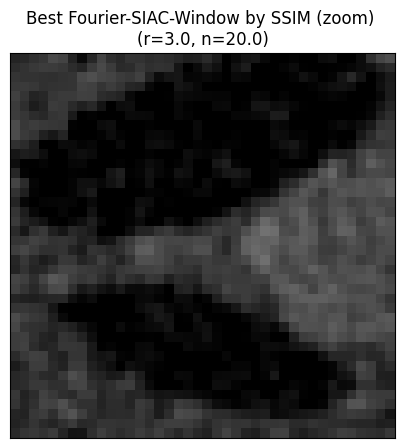

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Best Fourier-SIAC-Window by SSIM (zoom) \n(r=3.0, n=20.0)'}>)

In [10]:
### plot the best of each metric (no duplicates) ###
df_siac2 = df_summary[df_summary["method"] == "Fourier-SIAC-Window"].copy()

best_l2_row = df_siac2.loc[df_siac2["rel_l2_err"].idxmin()]
best_masked_l2_row = df_siac2.loc[df_siac2["masked_rel_l2_err"].idxmin()]
best_gw_ssim_row = df_siac2.loc[df_siac2["gw_ssim"].idxmax()]
best_ssim_row = df_siac2.loc[df_siac2["ssim"].idxmax()]

best_l2_name = best_l2_row["name"]
best_masked_l2_name = best_masked_l2_row["name"]
best_gwssim_name = best_gw_ssim_row["name"]
best_ssim_name = best_ssim_row["name"]

img_best_l2 = cases[best_l2_name]["image"]
img_best_masked_l2 = cases[best_masked_l2_name]["image"]
img_best_gwssim = cases[best_gwssim_name]["image"]
img_best_ssim = cases[best_ssim_name]["image"]

plot_img(img=fbp_hann, title="FBP (Hann)")
plot_img(
    img=img_best_l2,
    title=f"Best Fourier-SIAC-Window by rel L2\n(r={best_l2_row['moments']}, n={best_l2_row['BSorder']})"
)
plot_img(
    img=img_best_masked_l2,
    title=f"Best Fourier-SIAC-Window by masked rel L2\n(r={best_masked_l2_row['moments']}, n={best_masked_l2_row['BSorder']})"
)
plot_img(
    img=img_best_gwssim,
    title=f"Best Fourier-SIAC-Window by GW-SSIM\n(r={best_gw_ssim_row['moments']}, n={best_gw_ssim_row['BSorder']})"
)
plot_img(
    img=img_best_ssim,
    title=f"Best Fourier-SIAC-Window by SSIM\n(r={best_ssim_row['moments']}, n={best_ssim_row['BSorder']})"
)

plot_img_zoom(img=fbp_hann, title="FBP (Hann) (zoom)")
plot_img_zoom(
    img=img_best_l2,
    title=f"Best Fourier-SIAC-Window by rel L2 (zoom) \n(r={best_l2_row['moments']}, n={best_l2_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_masked_l2,
    title=f"Best Fourier-SIAC-Window by masked rel L2 (zoom) \n(r={best_masked_l2_row['moments']}, n={best_masked_l2_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_gwssim,
    title=f"Best Fourier-SIAC-Window by GW-SSIM (zoom) \n(r={best_gw_ssim_row['moments']}, n={best_gw_ssim_row['BSorder']})"
)
plot_img_zoom(
    img=img_best_ssim,
    title=f"Best Fourier-SIAC-Window by SSIM (zoom) \n(r={best_ssim_row['moments']}, n={best_ssim_row['BSorder']})"
)

### Plotting the filter in Fourier space

* Plotting the filter in Fourier space on a normalized, one sided, unit interval $t\in [0, 1]$. As ODL expects the filter to be on.

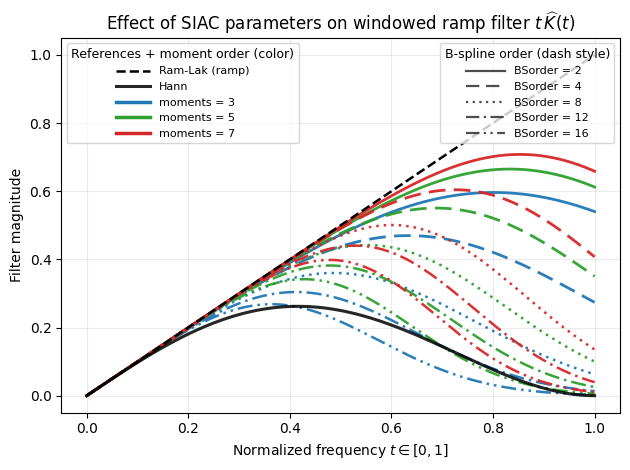

In [19]:
from src.utils import fbp_filters
from matplotlib.lines import Line2D
t = np.linspace(0.0, 1.0, 2001)

moments_list = [2, 4, 6]
BSorder_list = [2, 4, 8, 12, 16]

# Reference filters
H_ramp = fbp_filters(t, filter_type="Ram-Lak", frequency_scaling=1.0)
H_best = fbp_filters(t, filter_type="Hann", frequency_scaling=1.0)

# Style maps
colors = {2: "C0", 4: "C2", 6:"C3"}  # same color for same moments

# Use explicit dash patterns to make legend styles unmistakable
dash_map = {
    2: None,              # solid
    4: (6, 3),            # dashed
    8: (1, 2),            # dotted
    12: (6, 2, 1, 2),      # dash-dot
    16: (6, 2, 1, 2, 1, 2)  # dash-dot-dot
}

# Plot SIAC windowed ramp for each combo
for m in moments_list:
    for p in BSorder_list:
        H = siac_filter_odl(m, p, include_ramp=True)(t)
        (line,) = plt.plot(
            t, H,
            color=colors[m],
            linewidth=2.0 if p in (2, 4) else 1.8,
            alpha=0.95
        )
        # apply dash pattern (solid if None)
        if dash_map[p] is not None:
            line.set_dashes(dash_map[p])

plt.xlabel("Normalized frequency $t \\in [0,1]$")
plt.ylabel("Filter magnitude")
plt.title("Effect of SIAC parameters on windowed ramp filter $t\\,\\widehat K(t)$")
plt.grid(True, alpha=0.25)

# Plot references (store handles)
(ref_ramp,) = plt.plot(t, H_ramp, color="k", linewidth=1.8, linestyle="--", label="Ram-Lak (ramp)")
(ref_best,) = plt.plot(t, H_best, color="k", linewidth=2.2, linestyle="-", alpha=0.85, label=f"Hann")


ax = plt.gca()

# --- Left legend: references + moments (colors) ---
handles_left = [
    ref_ramp,
    ref_best,
    Line2D([0], [0], color=colors[2], lw=2.5, linestyle="-", label=f"moments = 3"),
    Line2D([0], [0], color=colors[4], lw=2.5, linestyle="-", label=f"moments = 5"),
    Line2D([0], [0], color=colors[6], lw=2.5, linestyle="-", label=f"moments = 7"),
]
leg1 = ax.legend(
    handles=handles_left,
    title="References + moment order (color)",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    handlelength=3.0
)
ax.add_artist(leg1)

# --- Right legend: BSorder (dash style) ---
handles_right = []
for p in BSorder_list:
    h = Line2D([0], [0], color="0.3", lw=1.6, linestyle="-", label=f"BSorder = {p}")
    if dash_map[p] is not None:
        h.set_dashes(dash_map[p])
    handles_right.append(h)

ax.legend(
    handles=handles_right,
    title="B-spline order (dash style)",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    handlelength=3.5
)

plt.tight_layout()
plt.show()

